In [1]:
# check which gpu we're using
!nvidia-smi

Wed Mar  4 09:58:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from urllib import request
import pandas as pd
import logging
import torch
from collections import Counter
from ast import literal_eval
import random

In [3]:
!pip install datasets accelerate
!pip install transformers==4.40.2
!pip install tensorboardx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follo

In [4]:
!pip list | grep transformers
!pip list | grep simpletransformers

sentence-transformers                    5.2.3
transformers                             4.40.2


In [5]:
# prepare logger
logging.basicConfig(level=logging.INFO)

transformers_logger = logging.getLogger("transformers")
transformers_logger.setLevel(logging.WARNING)

# check gpu
cuda_available = torch.cuda.is_available()

print('Cuda available? ',cuda_available)

if cuda_available:
  import tensorflow as tf
  # Get the GPU device name.
  device_name = tf.test.gpu_device_name()
  # The device name should look like the following:
  if device_name == '/device:GPU:0':
      print('Found GPU at: {}'.format(device_name))
  else:
      raise SystemError('GPU device not found')

Cuda available?  True
Found GPU at: /device:GPU:0


# Setting Up Don't Patronize Me

In [6]:
module_url = f"https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py"
module_name = module_url.split('/')[-1]
print(f'Fetching {module_url}')
#with open("file_1.txt") as f1, open("file_2.txt") as f2
with request.urlopen(module_url) as f, open(module_name,'w') as outf:
  a = f.read()
  outf.write(a.decode('utf-8'))

Fetching https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/dont_patronize_me.py


In [7]:
# helper function to save predictions to an output file
def labels2file(p, outf_path):
	with open(outf_path,'w') as outf:
		for pi in p:
			outf.write(','.join([str(k) for k in pi])+'\n')

In [8]:
from dont_patronize_me import DontPatronizeMe

dpm = DontPatronizeMe('.', '.')
dpm.load_task1()
dpm.load_task2(return_one_hot=True)

Map of label to numerical label:
{'Unbalanced_power_relations': 0, 'Shallow_solution': 1, 'Presupposition': 2, 'Authority_voice': 3, 'Metaphors': 4, 'Compassion': 5, 'The_poorer_the_merrier': 6}


In [9]:
trids = pd.read_csv('train_semeval_parids-labels.csv')
teids = pd.read_csv('dev_semeval_parids-labels.csv')

trids.par_id = trids.par_id.astype(str)
teids.par_id = teids.par_id.astype(str)

data=dpm.train_task1_df

# Building Data for Binary Classification

**Train Set**

In [10]:
rows = [] # will contain par_id, label and text
for idx in range(len(trids)):
  parid = trids.par_id[idx]
  #print(parid)
  # select row from original dataset to retrieve `text` and binary label
  keyword = data.loc[data.par_id == parid].keyword.values[0]
  text = data.loc[data.par_id == parid].text.values[0]
  label = data.loc[data.par_id == parid].label.values[0]
  rows.append({
      'par_id':parid,
      'community':keyword,
      'text':text,
      'label':label
  })
  trdf1 = pd.DataFrame(rows)

In [11]:
trdf1

,par_id,community,text,label
0,4341,poor-families,"The scheme saw an estimated 150,000 children f...",1
1,4136,homeless,Durban 's homeless communities reconciliation ...,1
2,10352,poor-families,The next immediate problem that cropped up was...,1
3,8279,vulnerable,Far more important than the implications for t...,1
4,1164,poor-families,To strengthen child-sensitive social protectio...,1
...,...,...,...,...
8370,8380,refugee,Rescue teams search for survivors on the rubbl...,0
8371,8381,hopeless,The launch of ' Happy Birthday ' took place la...,0
8372,8382,homeless,"The unrest has left at least 20,000 people dea...",0
8373,8383,hopeless,You have to see it from my perspective . I may...,0


**Test set**

In [12]:
rows = [] # will contain par_id, label and text
for idx in range(len(teids)):
  parid = teids.par_id[idx]
  #print(parid)
  # select row from original dataset
  keyword = data.loc[data.par_id == parid].keyword.values[0]
  text = data.loc[data.par_id == parid].text.values[0]
  label = data.loc[data.par_id == parid].label.values[0]
  rows.append({
      'par_id':parid,
      'community':keyword,
      'text':text,
      'label':label
  })
  tedf1 = pd.DataFrame(rows)

In [13]:
tedf1 = tedf1.sample(frac=1, random_state=42).reset_index(drop=True)

# Model and Training

## Data Augmentation

In [ ]:
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import numpy as np

# Download required NLTK data
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

class TextAugmenter:
    def __init__(self, seed=42):
        self.seed = seed
        np.random.seed(seed)
        random.seed(seed)

    def _get_synonyms(self, word, pos=None):
        """Get synonyms for a word using WordNet"""
        synonyms = set()
        for synset in wordnet.synsets(word):
            for lemma in synset.lemmas():
                if lemma.name() != word:
                    synonyms.add(lemma.name().replace('_', ' '))
        return list(synonyms)

    def _random_insertion(self, words, n=2):
        """Randomly insert n synonyms of random words"""
        new_words = words.copy()
        for _ in range(n):
            if len(new_words) == 0:
                return new_words
            random_word = random.choice(new_words)
            synonyms = self._get_synonyms(random_word)
            if len(synonyms) > 0:
                random_synonym = random.choice(synonyms)
                random_idx = random.randint(0, len(new_words) - 1)
                new_words.insert(random_idx, random_synonym)
        return new_words

    def _random_swap(self, words, n=2):
        """Randomly swap n pairs of words"""
        new_words = words.copy()
        for _ in range(n):
            if len(new_words) <= 1:
                return new_words
            idx1, idx2 = random.sample(range(len(new_words)), 2)
            new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
        return new_words

    def _random_deletion(self, words, p=0.1):
        """Randomly delete words with probability p"""
        if len(words) == 1:
            return words
        new_words = [word for word in words if random.uniform(0, 1) > p]
        return new_words if len(new_words) > 0 else words

    def _synonym_replacement(self, words, n=2):
        """Replace n random words with synonyms"""
        new_words = words.copy()
        random_word_list = list(set([word for word in words if word.isalpha()]))
        random.shuffle(random_word_list)

        num_replaced = 0
        for random_word in random_word_list:
            synonyms = self._get_synonyms(random_word)
            if len(synonyms) > 0:
                random_synonym = random.choice(synonyms)
                new_words = [random_synonym if word == random_word else word for word in new_words]
                num_replaced += 1
            if num_replaced >= n:
                break
        return new_words

    def augment(self, text, augmentation_type='mixed', intensity=0.5):
        """
        Augment text using specified technique

        Args:
            text: Input text string
            augmentation_type: 'synonym', 'insertion', 'swap', 'deletion', or 'mixed'
            intensity: 0.0-1.0, controls how much augmentation to apply

        Returns:
            Augmented text string
        """
        words = text.split()

        if augmentation_type == 'mixed':
            # pick exactly one op
            op = random.choice(['synonym', 'insertion', 'swap', 'deletion'])
            if op == 'synonym':
                n = 1
                words = self._synonym_replacement(words, n=n)
            elif op == 'insertion':
                n = 1
                words = self._random_insertion(words, n=n)
            elif op == 'swap':
                n = 1
                words = self._random_swap(words, n=n)
            elif op == 'deletion':
                p = 0.05
                words = self._random_deletion(words, p=p)
            return ' '.join(words)

# Initialize augmenter
augmenter = TextAugmenter(seed=42)
print("TextAugmenter initialized successfully!")

✓ TextAugmenter initialized successfully!


### Apply Augmentation to Training Data

Now we'll apply augmentation to the training data to create an augmented dataset for improved training

In [ ]:
AUGMENTATION_FACTOR    = 2      # minority class gets N extra augmented copies
AUGMENTATION_INTENSITY = 0.2   # how aggressively to augment

# Print class distribution for reference (no data materialised)
class_counts = trdf1['label'].value_counts().sort_index()
print("Original class distribution:")
print(class_counts.to_string())
print()

n_minority = int(class_counts.get(1, 0))
n_majority = int(class_counts.get(0, 0))
n_effective = n_majority + n_minority * (1 + AUGMENTATION_FACTOR)
print(f"Effective training size after lazy augmentation:")
print(f"Original        : {len(trdf1):,}")
print(f"After augment   : {n_effective:,}  (minority x {AUGMENTATION_FACTOR + 1})")
print(f"\nAugmentation config set — data will be generated on-the-fly during training.")

Original class distribution:
label
0    7581
1     794

Effective training size after lazy augmentation:
  Original        : 8,375
  After augment   : 9,963  (minority ×3)

✓ Augmentation config set — data will be generated on-the-fly during training.


## Loss Functions

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance
    Downweights easy examples and focuses on hard negatives

    Paper: Lin et al. "Focal Loss for Dense Object Detection" (2017)
    """
    def __init__(self, alpha_pos=0.815, alpha_neg=0.185, gamma=2.0):
        super().__init__()
        self.alpha_pos = alpha_pos
        self.alpha_neg = alpha_neg
        self.gamma = gamma

    def forward(self, logits, targets):
        # logits: [batch_size, 2] for binary
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)

        # create alpha factor per sample
        alpha_factor = torch.where(targets == 1, self.alpha_pos, self.alpha_neg)

        focal_loss = alpha_factor * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class DiceLoss(nn.Module):
    """
    Dice Loss (F1 Loss) - directly optimizes F1 score
    Useful for imbalanced classification tasks

    Dice coefficient = 2*TP / (2*TP + FP + FN)
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Convert logits to probabilities
        probs = F.softmax(logits, dim=1)

        # Get probabilities for positive class (class 1)
        pos_probs = probs[:, 1]

        # Convert targets to float
        targets_float = targets.float()

        # Calculate Dice coefficient
        intersection = (pos_probs * targets_float).sum()
        cardinality = pos_probs.sum() + targets_float.sum()

        dice_loss = 1 - (2 * intersection + self.smooth) / (cardinality + self.smooth)
        return dice_loss


class ContrastiveLoss(nn.Module):
    """
    Contrastive Loss - pulls same-class embeddings together, pushes different classes apart
    Useful for learning discriminative representations

    Applied to logit differences between positive and negative classes
    """
    def __init__(self, margin=1.0, temperature=0.07):
        super().__init__()
        self.margin = margin
        self.temperature = temperature

    def forward(self, logits, targets):
        # Get logits for both classes
        logits_pos_class = logits[:, 1]  # Logit for positive class
        logits_neg_class = logits[:, 0]  # Logit for negative class

        # Calculate similarity (difference in logits)
        similarity = logits_pos_class - logits_neg_class

        # Scale by temperature
        similarity = similarity / self.temperature

        # Contrastive loss: push correct class higher, wrong class lower
        targets_float = targets.float()

        # For positive samples: minimize -similarity
        # For negative samples: maximize similarity (so distance = margin - similarity)
        pos_loss = -similarity[targets == 1].mean()
        neg_loss = F.relu(self.margin - similarity[targets == 0]).mean()

        return pos_loss + neg_loss


class WeightedCrossEntropyLoss(nn.Module):
    """
    Standard Cross Entropy Loss with class weights
    Simpler alternative to Focal Loss, still addresses class imbalance
    """
    def __init__(self, weight_pos=0.815, weight_neg=0.185):
        super().__init__()
        self.weight_pos = weight_pos
        self.weight_neg = weight_neg

        # Create weight tensor
        weights = torch.tensor([weight_neg, weight_pos])
        self.register_buffer('weights', weights)

    def forward(self, logits, targets):
        return F.cross_entropy(logits, targets, weight=self.weights)


class CombinedLoss(nn.Module):
    """
    Combination of Focal Loss and Dice Loss for complementary strengths
    - Focal Loss: focuses on hard examples
    - Dice Loss: directly optimizes F1 score
    """
    def __init__(self, focal_weight=0.5, dice_weight=0.5, alpha_pos=0.815, alpha_neg=0.185, gamma=2.0):
        super().__init__()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight
        self.focal_loss = FocalLoss(alpha_pos=alpha_pos, alpha_neg=alpha_neg, gamma=gamma)
        self.dice_loss = DiceLoss()

    def forward(self, logits, targets):
        focal = self.focal_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.focal_weight * focal + self.dice_weight * dice


# Loss function registry for easy switching
LOSS_FUNCTIONS = {
    'focal': FocalLoss,
    'dice': DiceLoss,
    'contrastive': ContrastiveLoss,
    'weighted_ce': WeightedCrossEntropyLoss,
    'combined': CombinedLoss
}

print("✓ Loss functions loaded successfully!")
print(f"Available loss functions: {list(LOSS_FUNCTIONS.keys())}")

# **Dataset**

In [ ]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification


class TextDataset(Dataset):
    """
    Lightweight eval/inference dataset.
    Stores raw text strings and tokenises lazily in __getitem__ —
    NO pre-tokenised tensors are kept in memory.
    """
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts     = texts          # list[str]
        self.labels    = labels         # list[int]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


class AugmentedTextDataset(Dataset):
    """
    Memory-efficient training dataset with on-the-fly augmentation.

    Instead of pre-computing all augmented copies (which multiplies RAM usage
    by AUGMENTATION_FACTOR+1), this dataset:
      - stores only the original (text, label) pairs
      - expands the virtual index space so that minority-class samples appear
        AUGMENTATION_FACTOR extra times
      - generates augmented text on-the-fly in __getitem__, using a
        worker-local RNG seeded from (base_seed + worker_id) so that
        multi-worker DataLoader runs are reproducible and deterministic

    Args:
        df:                   DataFrame with 'text' and 'label' columns.
        tokenizer:            HuggingFace tokenizer.
        augmenter:            TextAugmenter instance.
        max_len:              Maximum token length.
        augmentation_factor:  How many extra augmented copies to create for
                              minority-class (label==1) samples.
        augmentation_intensity: Intensity passed to augmenter.augment().
        minority_label:       Which label value is the minority class (default 1).
        base_seed:            Base RNG seed; each DataLoader worker adds its
                              worker_id on top so augmentations differ per worker.
    """

    def __init__(
        self,
        df,
        tokenizer,
        augmenter,
        max_len=200,
        augmentation_factor=2,
        augmentation_intensity=0.3,
        minority_label=1,
        base_seed=42,
    ):
        self.tokenizer             = tokenizer
        self.augmenter             = augmenter
        self.max_len               = max_len
        self.augmentation_factor   = augmentation_factor
        self.augmentation_intensity = augmentation_intensity
        self.base_seed             = base_seed

        # Keep only the raw strings and integer labels — no tensors yet
        self.texts  = df['text'].tolist()          # list[str]
        self.labels = df['label'].astype(int).tolist()  # list[int]

        # Build an index table: each row maps virtual_idx → (real_idx, is_augmented)
        # Original samples come first, then the extra augmented copies.
        index_table = []
        for real_idx, label in enumerate(self.labels):
            index_table.append((real_idx, False))   # always keep the original
            if label == minority_label:
                for _ in range(augmentation_factor):
                    index_table.append((real_idx, True))   # augmented copy

        self._index = index_table   # list[(real_idx, augment_flag)]

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        real_idx, do_augment = self._index[idx]
        text  = self.texts[real_idx]
        label = self.labels[real_idx]
        text.lower()

        if do_augment:
            # Worker-local RNG: seed from base + worker_id so each worker
            # produces different augmentations (avoids all workers returning
            # identical copies within the same batch).
            worker_info = torch.utils.data.get_worker_info()
            if worker_info is not None:
                seed = self.base_seed + worker_info.id + idx
            else:
                seed = self.base_seed + idx
            import random as _rnd
            _rnd.seed(seed)

            text = self.augmenter.augment(
                text,
                augmentation_type='mixed',
                intensity=self.augmentation_intensity,
            )

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(label, dtype=torch.long),
        }


def make_loader(dataset, batch_size, shuffle=False, num_workers=None, pin_memory=None):
    """
    Create a DataLoader with sensible defaults for the current device.

    num_workers:
      - Defaults to min(4, os.cpu_count()) when the tokenizer is thread-safe
        (fast tokenizer) and augmentation is happening (training loader).
      - For eval loaders where shuffle=False, workers still help pipeline I/O.
      - Set num_workers=0 to disable multiprocessing (useful for debugging).

    pin_memory:
      - Enabled automatically when a CUDA GPU is available.
      - Ignored silently on CPU / MPS (no-op there).
    """
    if num_workers is None:
        num_workers = min(4, os.cpu_count() or 1)
    if pin_memory is None:
        pin_memory = torch.cuda.is_available()

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )


print("TextDataset, AugmentedTextDataset and make_loader defined.")
print("AugmentedTextDataset: on-the-fly augmentation, zero extra RAM for copies")
print("make_loader: auto num_workers + pin_memory based on device")


✓ TextDataset, AugmentedTextDataset and make_loader defined.
  • AugmentedTextDataset: on-the-fly augmentation, zero extra RAM for copies
  • make_loader: auto num_workers + pin_memory based on device


# **Pre-trained DeRoberta Model**

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

class CustomClassificationHead(nn.Module):
    """
    Configurable classification head for custom models.
    Allows for flexible architecture design on top of feature extractors.

    Args:
        input_dim: Dimension of input features (usually hidden_size of base model)
        hidden_dims: List of hidden layer dimensions, e.g., [768, 256, 128]
        num_classes: Number of output classes (2 for binary classification)
        dropout_rate: Dropout probability for regularization
        activation: Activation function ('relu', 'gelu', 'tanh')
        use_layer_norm: Whether to use layer normalization between layers
        use_batch_norm: Whether to use batch normalization between layers
    """
    def __init__(
        self,
        input_dim=768,
        hidden_dims=[512, 256],
        num_classes=2,
        dropout_rate=0.4,
        activation='silu',
        use_layer_norm=True,
        use_batch_norm=False
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        # Activation factory: creates a FRESH instance per layer.
        # IMPORTANT: never reuse the same nn.Module instance across layers in
        # nn.Sequential — shared instances cause incorrect gradient accumulation
        # through the activation, leading to NaN loss when the encoder is unfrozen.
        activation_factories = {
            'relu': nn.ReLU,
            'gelu': nn.GELU,
            'tanh': nn.Tanh,
            'elu': nn.ELU,
            'silu': nn.SiLU,
        }
        if activation not in activation_factories:
            raise ValueError(f"Unknown activation '{activation}'. Choose from {list(activation_factories.keys())}")
        self._activation_factory = activation_factories[activation]

        # Build layers
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if use_layer_norm:
                layers.append(nn.LayerNorm(hidden_dim))

            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            # Fresh activation instance for each hidden layer
            layers.append(nn.SiLU())

            layers.append(nn.Dropout(dropout_rate))

            prev_dim = hidden_dim

        # Output layer (no activation)
        layers.append(nn.Linear(prev_dim, num_classes))

        self.classifier = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        """Initialize weights using Xavier uniform initialization"""
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, input_dim)

        Returns:
            logits: Output logits of shape (batch_size, num_classes)
        """
        # Ensure input is float32 to match classification head weights
        x = x.float()
        return self.classifier(x)

class BiLSTMClassificationHead(nn.Module):
    def __init__(
        self,
        input_dim: int = 768,
        proj_dim: int = 128,
        seq_len: int = 6,
        hidden_dim: int = 256,
        num_layers: int = 2,
        num_classes: int = 2,
        dropout: float = 0.3,
        pooling: str = 'mean',       # last mean max
        fc_hidden_dims: list = None,
        expand_mode: str = 'project',
        **kwargs,                    # absorb unknown keys (e.g. head_type)
    ):
        super().__init__()
        self.seq_len    = seq_len
        self.proj_dim   = proj_dim
        self.hidden_dim = hidden_dim
        self.pooling    = pooling

        self.expand = nn.Linear(input_dim, seq_len * proj_dim)

        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        lstm_out_dim = hidden_dim * 2          # bidirectional concat
        if fc_hidden_dims is None:
            fc_hidden_dims = []

        head_layers = []
        prev_dim = lstm_out_dim
        for h in fc_hidden_dims:
            head_layers += [
                nn.Linear(prev_dim, h),
                nn.LayerNorm(h),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        head_layers.append(nn.Linear(prev_dim, num_classes))
        self.classifier = nn.Sequential(*head_layers)

        self.drop = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.expand.weight)
        nn.init.zeros_(self.expand.bias)
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
                n = param.size(0)
                param.data[n // 4: n // 2].fill_(1.0)
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def _pool(self, lstm_out):
        """lstm_out: (B, seq_len, 2*H)  — all steps are real (no padding here)"""
        if self.pooling == 'last':
            return lstm_out[:, -1, :]
        elif self.pooling == 'mean':
            return lstm_out.mean(dim=1)
        elif self.pooling == 'max':
            return lstm_out.max(dim=1).values
        else:
            raise ValueError(f"Unknown pooling '{self.pooling}'. Choose last/mean/max.")

    def forward(self, x):
        """
        Args:
            x: (B, input_dim)  — pooled encoder output (float32)
        Returns:
            logits: (B, num_classes)
        """
        x = x.float()
        # Expand to pseudo-sequence: (B, seq_len * proj_dim) → (B, seq_len, proj_dim)
        expanded = self.expand(x).view(x.size(0), self.seq_len, self.proj_dim)
        expanded = self.drop(expanded)

        lstm_out, _ = self.lstm(expanded)          # (B, seq_len, 2*H)
        pooled      = self._pool(lstm_out)         # (B, 2*H)
        pooled      = self.drop(pooled)
        return self.classifier(pooled)             # (B, num_classes)

class DeBERTaFeatureExtractorModel(nn.Module):
    """
    DeBERTa model with custom classification head.
    Combines DeBERTa as feature extractor with a configurable classification head.

    Args:
        model_name: HuggingFace model identifier
        classification_head_config: Dictionary with classification head configuration
        pooling_strategy: How to aggregate token representations ('mean', 'max', 'cls', 'attention')
        freeze_encoder: Whether to freeze DeBERTa encoder weights
        encoder_lr_multiplier: Learning rate multiplier for encoder (useful for discriminative fine-tuning)
    """
    def __init__(
        self,
        model_name="microsoft/deberta-v3-base",
        classification_head_config=None,
        pooling_strategy='mean',
        freeze_encoder=False,
        encoder_lr_multiplier=1.0
    ):
        super().__init__()

        self.model_name = model_name
        self.pooling_strategy = pooling_strategy
        self.encoder_lr_multiplier = encoder_lr_multiplier

        # Load DeBERTa as feature extractor (not for classification)
        self.encoder = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.encoder.config.hidden_size

        # Freeze encoder if specified
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print(f"✓ DeBERTa encoder frozen")

        # Setup pooling layer for attention-based pooling
        if pooling_strategy == 'attention':
            self.attention_weights = nn.Linear(self.hidden_size, 1)

        if classification_head_config is None:
            classification_head_config = {
                'head_type':    'mlp',
                'hidden_dims':  [512, 256],
                'num_classes':  2,
                'dropout_rate': 0.3,
                'activation':   'gelu',
                'use_layer_norm': True,
                'use_batch_norm': False,
            }

        cfg = dict(classification_head_config)
        cfg['input_dim'] = self.hidden_size
        head_type = cfg.pop('head_type', 'mlp')

        if head_type == 'mlp':
            self.classification_head = CustomClassificationHead(**cfg)
        elif head_type == 'bilstm':
            self.classification_head = BiLSTMClassificationHead(**cfg)
        else:
            raise ValueError(f"Unknown head_type '{head_type}'. Choose 'mlp' or 'bilstm'.")

        self.config = cfg

    def _pool_output(self, last_hidden_state, attention_mask):
        """
        Pool the token-level outputs into a single representation.

        Args:
            last_hidden_state: (batch_size, seq_len, hidden_size)
            attention_mask: (batch_size, seq_len)

        Returns:
            pooled: (batch_size, hidden_size)
        """
        if self.pooling_strategy == 'cls':
            # Use [CLS] token (first token)
            pooled = last_hidden_state[:, 0, :]

        elif self.pooling_strategy == 'mean':
            # Mean pooling with attention mask
            mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
            sum_embeddings = (last_hidden_state.float() * mask_expanded).sum(1)
            sum_mask = mask_expanded.sum(1).clamp(min=1e-9)
            pooled = sum_embeddings / sum_mask

        elif self.pooling_strategy == 'max':
            mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size())
            lhs = last_hidden_state.float().clone()
            lhs[~mask_expanded.bool()] = -1e9
            pooled = torch.max(lhs, 1)[0]

        elif self.pooling_strategy == 'attention':
            lhs_float = last_hidden_state.float()

            attention_scores = self.attention_weights(lhs_float).squeeze(-1)

            mask = attention_mask.bool()
            attention_scores[~mask] = -1e9

            attn_weights = torch.softmax(attention_scores, dim=-1)

            pooled = torch.bmm(attn_weights.unsqueeze(1), lhs_float).squeeze(1)

        else:
            raise ValueError(f"Unknown pooling strategy: {self.pooling_strategy}")

        return pooled

    def forward(self, input_ids, attention_mask):
        encoder_output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        last_hidden_state = encoder_output.last_hidden_state

        # Pool token-level representations
        pooled = self._pool_output(last_hidden_state, attention_mask)

        # Pass through classification head (casts to float32 internally)
        logits = self.classification_head(pooled)

        return logits


# Configuration presets for different classification head architectures
CLASSIFICATION_HEAD_PRESETS = {
    # This has the same classification head structure as deberta v3 large from autoclassifier
    'simple': {
        'head_type': 'mlp',
        'hidden_dims': [1024],
        'dropout_rate': 0.1,
        'activation': 'silu',
        'use_layer_norm': False,
        'use_batch_norm': False
    },
    'medium': {
        'head_type': 'mlp',
        'hidden_dims': [512, 256],
        'dropout_rate': 0.3,
        'activation': 'gelu',
        'use_layer_norm': True,
        'use_batch_norm': False
    },
    'large': {
        'head_type': 'mlp',
        'hidden_dims': [768, 512, 256],
        'dropout_rate': 0.6,
        'activation': 'silu',
        'use_layer_norm': True,
        'use_batch_norm': False
    },
    'minimal': {
        'head_type': 'mlp',
        'hidden_dims': [],  # Direct projection to num_classes
        'dropout_rate': 0.1,
        'activation': 'gelu',
        'use_layer_norm': False,
        'use_batch_norm': False
    },
    'bilstm_small': {
        'head_type': 'bilstm',
        'proj_dim': 64, 'seq_len': 4, 'hidden_dim': 128, 'num_layers': 1,
        'dropout': 0.2, 'pooling': 'mean', 'fc_hidden_dims': [],
    },
    'bilstm_medium': {
        'head_type': 'bilstm',
        'proj_dim': 128, 'seq_len': 6, 'hidden_dim': 256, 'num_layers': 2,
        'dropout': 0.3, 'pooling': 'mean', 'fc_hidden_dims': [256],
    },
    'bilstm_large': {
        'head_type': 'bilstm',
        'proj_dim': 192, 'seq_len': 8, 'hidden_dim': 384, 'num_layers': 2,
        'dropout': 0.3, 'pooling': 'mean', 'fc_hidden_dims': [384, 256],
    },
}

print("Custom DeBERTa Feature Extractor model loaded!")
print(f"Available classification head presets: {list(CLASSIFICATION_HEAD_PRESETS.keys())}")

✓ Custom DeBERTa Feature Extractor model loaded!
Available classification head presets: ['simple', 'medium', 'large', 'minimal', 'bilstm_small', 'bilstm_medium', 'bilstm_large']


# Training Set Up

In [ ]:
BATCH_SIZE = 64
USE_AUGMENTED_DATA = False
USE_CUSTOM_MODEL = False  # Set to True to use custom model instead of default AutoModelForSequenceClassification
# used to train the same model under the same training regime at a few different random init points
random.seed(6023)

# Choose which loss function to use. Options: 'focal', 'dice', 'contrastive', 'weighted_ce', 'combined'
LOSS_FUNCTION_NAME = 'focal'
model_name = "microsoft/deberta-v3-large"
# model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# The dataset averages around 50 words per text snippet. 128 should be more than enough
MAX_LEN = 200
tokenizer.model_max_length = MAX_LEN

# Loss function configuration
LOSS_CONFIG = {
    'focal': {'alpha_pos': 0.905, 'alpha_neg': 0.095, 'gamma': 1.0},
    'dice': {'smooth': 1.0},
    'contrastive': {'margin': 1.0, 'temperature': 0.07},
    'weighted_ce': {'weight_pos': 0.5, 'weight_neg': 0.5},
    'combined': {'focal_weight': 0.5, 'dice_weight': 0.5, 'alpha_pos': 0.815, 'alpha_neg': 0.185, 'gamma': 2.0}
}

# Initialize selected loss function
if LOSS_FUNCTION_NAME not in LOSS_FUNCTIONS:
    raise ValueError(f"Loss function '{LOSS_FUNCTION_NAME}' not available. Choose from {list(LOSS_FUNCTIONS.keys())}")

criterion = LOSS_FUNCTIONS[LOSS_FUNCTION_NAME](**LOSS_CONFIG[LOSS_FUNCTION_NAME])
print(f"✓ Using {LOSS_FUNCTION_NAME.upper()} loss function")
print(f"  Config: {LOSS_CONFIG[LOSS_FUNCTION_NAME]}")

# Dataloader - using augmented training data
if USE_AUGMENTED_DATA:
  train_dataset = AugmentedTextDataset(
    df=trdf1,
    tokenizer=tokenizer,
    augmenter=augmenter,
    max_len=MAX_LEN,
    augmentation_factor=AUGMENTATION_FACTOR,
    augmentation_intensity=AUGMENTATION_INTENSITY,
    minority_label=1,
    base_seed=42,
  )
  print(f"\nAugmentedTextDataset  |  virtual size: {len(train_dataset):,}  (original: {len(trdf1):,})")
else:
  train_dataset = TextDataset(trdf1.text.tolist(), trdf1.label.tolist(), tokenizer, max_len=MAX_LEN)
  print(f"\nTextDataset (no augmentation)  |  size: {len(train_dataset):,}")

test_dataset = TextDataset(tedf1.text.tolist(), tedf1.label.tolist(), tokenizer, max_len=MAX_LEN)

train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = make_loader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

import platform

def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"CUDA available - using GPU: {torch.cuda.get_device_name(0)}")
        return device
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        # Check if MPS is built correctly
        try:
            test_tensor = torch.randn(10, 10, device=device)
        except Exception as e:
            print(f"Falling back to CPU...")
            return torch.device("cpu")
        return device
    else:
        device = torch.device("cpu")
        print(f"No GPU available - using CPU")
        return device

device = get_device()

if USE_CUSTOM_MODEL:
    print("\n" + "="*80)
    print("INITIALIZING CUSTOM DEBERTA FEATURE EXTRACTOR MODEL")
    print("="*80)

    # Choose classification head architecture
    HEAD_PRESET = 'simple'  # Options: 'simple', 'medium', 'large', 'minimal'

    # Get preset configuration
    head_config = CLASSIFICATION_HEAD_PRESETS[HEAD_PRESET].copy()
    head_config['num_classes'] = 2

    # Create custom model
    custom_model = DeBERTaFeatureExtractorModel(
        model_name=model_name,
        classification_head_config=head_config,
        pooling_strategy='attention',  # Options: 'cls', 'mean', 'max', 'attention'
        freeze_encoder=True,  # Set to True to freeze encoder weights
        encoder_lr_multiplier=0.1  # Lower learning rate for encoder
    )

    # Move to device
    custom_model.to(device)

    print(f"Custom model created with '{HEAD_PRESET}' classification head")
    print(f"\nClassification Head Configuration:")
    for key, value in head_config.items():
        print(f"  {key}: {value}")

    print(f"\nPooling Strategy: {custom_model.pooling_strategy}")
    print(f"Encoder LR Multiplier: {custom_model.encoder_lr_multiplier}")

    # Count trainable parameters
    total_params = sum(p.numel() for p in custom_model.parameters())
    trainable_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)

    print(f"\nModel Parameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,}")
    print(f"  Frozen: {total_params - trainable_params:,}")

    print("\n" + "="*80)

else:
    print("Using default AutoModelForSequenceClassification")
    print("(Set USE_CUSTOM_MODEL = True to switch to custom DeBERTa feature extractor model)")

# Optimizer
if USE_CUSTOM_MODEL:
    # Discriminative fine-tuning: different learning rates for encoder vs head
    model = custom_model
else:
  model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
  optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

model.to(device)
criterion.to(device)

print(f"\nModel and Loss Function initialized on device: {device}")

✓ Using FOCAL loss function
  Config: {'alpha_pos': 0.905, 'alpha_neg': 0.095, 'gamma': 1.0}

✓ TextDataset (no augmentation)  |  size: 8,375
✓ CUDA available - using GPU: NVIDIA A100-SXM4-40GB
  CUDA Version: 12.8
  Device Count: 1
✓ Using default AutoModelForSequenceClassification
  (Set USE_CUSTOM_MODEL = True to switch to custom DeBERTa feature extractor model)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✓ Model and Loss Function initialized on device: cuda


# Normal Training

In [26]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import numpy as np # Ensure numpy is imported
import torch.nn.functional as F # Ensure F is imported for softmax

# Training loop
model.train()
best_f1 = 0.0
best_epoch = -1
save_path = "best_model_f1.pt"

for epoch in range(10):
    total_train_loss = 0
    # Wrap train_loader with tqdm for a progress bar
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    for batch_idx, batch in enumerate(pbar):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits if hasattr(outputs, 'logits') else outputs
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        # Update postfix with current batch loss
        pbar.set_postfix({'batch_loss': loss.item(), 'average loss': total_train_loss / (batch_idx + 1)})

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} Training Loss: {avg_train_loss:.4f}")

    # Evaluation phase
    model.eval() # Set model to evaluation mode
    total_test_loss = 0
    all_predictions = [] # This will still store the argmax predictions as a baseline
    all_probabilities = [] # To store probabilities for thresholding
    all_true_labels = []

    # Wrap test_loader with tqdm for a progress bar during evaluation
    eval_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1} Evaluating")
    with torch.no_grad(): # Disable gradient calculations during evaluation
        total_val_loss = 0
        for batch_idx, batch in enumerate(eval_pbar):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            loss = criterion(logits, labels)
            total_test_loss += loss.item()

            # Store argmax predictions for baseline F1/Accuracy
            predictions = torch.argmax(logits, dim=1).cpu().numpy()
            all_predictions.extend(predictions)

            # Store probabilities for threshold-based evaluation
            probabilities = F.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probability of positive class
            all_probabilities.extend(probabilities)

            true_labels_batch = labels.cpu().numpy()
            all_true_labels.extend(true_labels_batch)

            total_val_loss += loss.item()
            eval_pbar.set_postfix({'batch_loss': loss.item(), 'average loss': total_val_loss / (batch_idx + 1)})

    avg_test_loss = total_test_loss / len(test_loader)

    # Calculate and print F1/Accuracy for original argmax predictions
    f1_argmax = f1_score(all_true_labels, all_predictions, average='binary')
    accuracy_argmax = accuracy_score(all_true_labels, all_predictions)
    print(f"Epoch {epoch+1} Test Loss: {avg_test_loss:.4f}, Baseline (argmax) F1 Score: {f1_argmax:.4f}, Accuracy: {accuracy_argmax:.4f}")

    # Evaluate with different thresholds
    thresholds = np.arange(0.1, 1.0, 0.1)

    best_epoch_f1 = 0.0
    best_epoch_threshold = None

    for threshold in thresholds:
        threshold_predictions = (np.array(all_probabilities) >= threshold).astype(int)
        f1_thresh = f1_score(all_true_labels, threshold_predictions, average='binary')

        if f1_thresh > best_epoch_f1:
            best_epoch_f1 = f1_thresh
            best_epoch_threshold = threshold

    print(
        f"Epoch {epoch+1} Best Threshold F1: {best_epoch_f1:.4f} "
        f"(threshold={best_epoch_threshold:.2f})"
    )

    if best_epoch_f1 > best_f1:
      best_f1 = best_epoch_f1
      best_epoch = epoch + 1

      torch.save({
          "epoch": best_epoch,
          "model_state_dict": model.state_dict(),
          "optimizer_state_dict": optimizer.state_dict(),
          "best_f1": best_f1,
          "best_threshold": best_epoch_threshold
      }, save_path)
      torch.save(model, "best_model_full.pt")

      print(f"✅ Saved new best model (F1={best_f1:.4f})")

    model.train() # Set model back to training mode

Epoch 1 Training:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 1 Training Loss: 0.0492


Epoch 1 Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1 Test Loss: 0.0360, Baseline (argmax) F1 Score: 0.5024, Accuracy: 0.8515
Epoch 1 Best Threshold F1: 0.5171 (threshold=0.60)
✅ Saved new best model (F1=0.5171)


Epoch 2 Training:   0%|          | 0/131 [00:00<?, ?it/s]

...

Epoch 9 Test Loss: 0.0676, Baseline (argmax) F1 Score: 0.5703, Accuracy: 0.8978
Epoch 9 Best Threshold F1: 0.5811 (threshold=0.60)


Epoch 10 Training:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch 10 Training Loss: 0.0078


Epoch 10 Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 10 Test Loss: 0.0843, Baseline (argmax) F1 Score: 0.5525, Accuracy: 0.9226
Epoch 10 Best Threshold F1: 0.5887 (threshold=0.20)


# Training with Gradual Unfreezing

In [20]:
def get_encoder_layer_groups(model):
    """
    Return the transformer layers of the DeBERTa encoder as an ordered list
    (index 0 = first/lowest layer, index N-1 = last/topmost layer).
    Works for DeBERTa-v3 whose layers live at encoder.encoder.layer.
    """
    return list(model.encoder.encoder.layer)

def freeze_encoder(model):
    """Freeze ALL encoder parameters (embeddings + every transformer layer)."""
    for param in model.encoder.parameters():
        param.requires_grad = False

def unfreeze_encoder(model):
    """Unfreeze ALL encoder parameters (embeddings + every transformer layer)."""
    for param in model.encoder.parameters():
        param.requires_grad = True


def unfreeze_top_n_layers(model, n_layers):
    """
    Unfreeze the top-n transformer layers of the encoder
    (i.e., the last n layers closest to the output).

    When n_layers >= total layers the entire encoder (including embeddings)
    is unfrozen, so 'Frozen: 0' is achievable.
    """
    layers = get_encoder_layer_groups(model)
    total = len(layers)

    if n_layers >= total:
        # Unfreeze everything — embeddings included
        unfreeze_encoder(model)
    else:
        # Only unfreeze the top-n transformer blocks; embeddings stay frozen
        for layer in layers[total - n_layers:]:
            for param in layer.parameters():
                param.requires_grad = True


def rebuild_optimizer(model, head_lr=1e-4, encoder_lr=1e-5):
    """
    Build a fresh AdamW optimizer with two parameter groups:
      - classifier head  → head_lr   (always trained)
      - encoder params   → encoder_lr (only those with requires_grad=True)

    Rebuilding after each requires_grad change ensures the optimizer state
    covers exactly the currently-trainable parameters.
    """
    head_params = list(model.classification_head.parameters())

    # Include attention_weights pool layer if present
    extra_params = []
    if hasattr(model, 'attention_weights'):
        extra_params = list(model.attention_weights.parameters())

    encoder_trainable = [p for p in model.encoder.parameters() if p.requires_grad]

    param_groups = [{'params': head_params + extra_params, 'lr': head_lr}]
    if encoder_trainable:
        param_groups.append({'params': encoder_trainable, 'lr': encoder_lr})

    return torch.optim.AdamW(param_groups, weight_decay=0.01)

In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import numpy as np
import torch.nn.functional as F
from transformers import get_cosine_schedule_with_warmup

WARMUP_EPOCHS   = 1   # epochs where only the head is trained
LAYERS_PER_STEP = 3   # extra layers to unfreeze each epoch after warmup
NUM_EPOCHS      = 20   # total training epochs (increase as needed)
HEAD_LR         = 2e-5 # learning rate for classifier head
ENCODER_LR      = 1e-5 # learning rate for unfrozen encoder layers

def report_trainable(model, epoch):
    total   = sum(p.numel() for p in model.parameters())
    active  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen  = total - active
    print(f"\n{'='*60}")
    print(f"  Epoch {epoch}  |  Trainable: {active:,}  |  Frozen: {frozen:,}")
    print(f"{'='*60}")


model.train()
best_f1    = 0
best_epoch = 0
save_path  = "best_model_f1_deberta_g1_simple.pt"
full_opened = False
unfreezing = False

# build optimizer
encoder_params = list(custom_model.encoder.parameters())
head_params = list(custom_model.classification_head.parameters())
optimizer = torch.optim.Adam([
      {'params': encoder_params, 'lr': ENCODER_LR},
      {'params': head_params, 'lr': HEAD_LR}
    ],
)
num_training_steps = NUM_EPOCHS * len(train_loader)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

# Total encoder layers (12 for DeBERTa-v3-base)
target_layers = None
if target_layers == None:
  target_layers = len(get_encoder_layer_groups(model)) if USE_CUSTOM_MODEL else 0

for epoch in range(0, NUM_EPOCHS):
    epoch_num = epoch + 1  # 1-indexed

    if USE_CUSTOM_MODEL:
        if epoch_num <= WARMUP_EPOCHS:
            freeze_encoder(model)
            print(f"\n[Epoch {epoch_num}] WARMUP: encoder fully frozen, training head only")

        else:
            extra_epochs   = epoch_num - WARMUP_EPOCHS          # 1, 2, 3, …
            layers_to_open = extra_epochs * LAYERS_PER_STEP     # 2, 4, 6, …
            layers_to_open = min(layers_to_open, target_layers)  # cap at total

            # Re-freeze everything first, then selectively unfreeze top N layers
            freeze_encoder(model)
            unfreeze_top_n_layers(model, layers_to_open)

            # Rebuild optimizer to include the newly-unfrozen encoder params
            if (layers_to_open >= target_layers)and not full_opened:
              # Drastically reduce encoder lr after embedding layers are unfrozen
              optimizer.param_groups[0]["lr"] = HEAD_LR / 2
              optimizer.param_groups[1]["lr"] = ENCODER_LR / 2
              full_opened = True
            elif layers_to_open < target_layers and not unfreezing:
              # optimizer = rebuild_optimizer(model, head_lr= HEAD_LR, encoder_lr=ENCODER_LR * (0.9 ** epoch))
              unfreezing = True

            if layers_to_open >= target_layers:
                print(f"\n[Epoch {epoch_num}] ALL {target_layers} encoder layers unfrozen + head")
            else:
                print(
                    f"\n[Epoch {epoch_num}] Top {layers_to_open}/{target_layers} "
                    f"encoder layers unfrozen + head"
                )

        report_trainable(model, epoch_num)

    model.train()
    total_train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch_num} Training")

    for batch_idx, batch in enumerate(pbar):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits if hasattr(outputs, 'logits') else outputs
        loss    = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        pbar.set_postfix({
            'batch_loss':   loss.item(),
            'average_loss': total_train_loss / (batch_idx + 1)
        })

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch_num} Training Loss: {avg_train_loss:.4f}")

    model.eval()
    total_test_loss  = 0
    all_predictions  = []
    all_probabilities = []
    all_true_labels  = []

    eval_pbar = tqdm(test_loader, desc=f"Epoch {epoch_num} Evaluating")
    with torch.no_grad():
        total_val_loss = 0
        for batch_idx, batch in enumerate(eval_pbar):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs
            loss    = criterion(logits, labels)
            total_test_loss += loss.item()

            predictions = torch.argmax(logits, dim=1).cpu().numpy()
            all_predictions.extend(predictions)

            probabilities = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probabilities.extend(probabilities)

            all_true_labels.extend(labels.cpu().numpy())

            total_val_loss += loss.item()
            eval_pbar.set_postfix({
                'batch_loss':   loss.item(),
                'average_loss': total_val_loss / (batch_idx + 1)
            })

    avg_test_loss = total_test_loss / len(test_loader)

    # Argmax baseline metrics
    f1_argmax       = f1_score(all_true_labels, all_predictions, average='binary')
    accuracy_argmax = accuracy_score(all_true_labels, all_predictions)
    print(
        f"Epoch {epoch_num} Test Loss: {avg_test_loss:.4f}, "
        f"Baseline (argmax) F1 Score: {f1_argmax:.4f}, "
        f"Accuracy: {accuracy_argmax:.4f}"
    )

    # Threshold sweep
    thresholds        = np.arange(0.1, 1.0, 0.1)
    best_epoch_f1     = 0.0
    best_epoch_threshold = None

    print(f"  Evaluating with thresholds:")
    for threshold in thresholds:
        threshold_predictions = (np.array(all_probabilities) >= threshold).astype(int)
        f1_thresh = f1_score(all_true_labels, threshold_predictions, average='binary')
        accuracy_thresh = accuracy_score(all_true_labels, threshold_predictions)
        print(f"    Threshold {threshold:.1f}: F1 Score: {f1_thresh:.4f}, Accuracy: {accuracy_thresh:.4f}")
        if f1_thresh > best_epoch_f1:
            best_epoch_f1        = f1_thresh
            best_epoch_threshold = threshold

    print(
        f"Epoch {epoch_num} Best Threshold F1: {best_epoch_f1:.4f} "
        f"(threshold={(best_epoch_threshold if best_epoch_threshold is not None else 0):.2f})"
    )

    # Save best model
    if best_epoch_f1 > best_f1:
        best_f1    = best_epoch_f1
        best_epoch = epoch_num

        torch.save({
            "epoch":               best_epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_f1":             best_f1,
            "best_threshold":      best_epoch_threshold
        }, save_path)

        # Also save the full model object — allows loading without rebuilding the architecture
        torch.save(model, "best_model_full_deberta_g1_simple.pt")

        print(f"Saved new best model (F1={best_f1:.4f})")
        print(f"State-dict checkpoint → {save_path}")
        print(f"Full model object     → best_model_full_deberta_grad.pt")

    model.train()  # restore training mode for next epoch


[Epoch 1] WARMUP: encoder fully frozen, training head only

  Epoch 1  |  Trainable: 1,052,675  |  Frozen: 434,012,160


Epoch 1 Training:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch 1 Training Loss: 0.0613


Epoch 1 Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 1 Test Loss: 0.0548, Baseline (argmax) F1 Score: 0.2971, Accuracy: 0.7221
  Evaluating with thresholds:
    Threshold 0.1: F1 Score: 0.1736, Accuracy: 0.0950
    Threshold 0.2: F1 Score: 0.1736, Accuracy: 0.0950
    Threshold 0.3: F1 Score: 0.1738, Accuracy: 0.0965
    Threshold 0.4: F1 Score: 0.1969, Accuracy: 0.2483
    Threshold 0.5: F1 Score: 0.2971, Accuracy: 0.7221
    Threshold 0.6: F1 Score: 0.0541, Accuracy: 0.8997
    Threshold 0.7: F1 Score: 0.0000, Accuracy: 0.9050
    Threshold 0.8: F1 Score: 0.0000, Accuracy: 0.9050
    Threshold 0.9: F1 Score: 0.0000, Accuracy: 0.9050
Epoch 1 Best Threshold F1: 0.2971 (threshold=0.50)
Saved new best model (F1=0.2971)
State-dict checkpoint → best_model_f1_deberta_g1_simple.pt
Full model object     → best_model_full_deberta_grad.pt

[Epoch 2] Top 3/24 encoder layers unfrozen + head

  Epoch 2  |  Trainable: 38,841,347  |  Frozen: 396,223,488


...

Epoch 12 Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 12 Test Loss: 0.1322, Baseline (argmax) F1 Score: 0.5667, Accuracy: 0.9131
  Evaluating with thresholds:
    Threshold 0.1: F1 Score: 0.5505, Accuracy: 0.8830
    Threshold 0.2: F1 Score: 0.5673, Accuracy: 0.9002
    Threshold 0.3: F1 Score: 0.5789, Accuracy: 0.9083
    Threshold 0.4: F1 Score: 0.5747, Accuracy: 0.9117
    Threshold 0.5: F1 Score: 0.5667, Accuracy: 0.9131
    Threshold 0.6: F1 Score: 0.5620, Accuracy: 0.9174
    Threshold 0.7: F1 Score: 0.5561, Accuracy: 0.9207
    Threshold 0.8: F1 Score: 0.5490, Accuracy: 0.9231
    Threshold 0.9: F1 Score: 0.5152, Accuracy: 0.9236
Epoch 12 Best Threshold F1: 0.5789 (threshold=0.30)

[Epoch 13] ALL 24 encoder layers unfrozen + head

  Epoch 13  |  Trainable: 435,064,835  |  Frozen: 0


Epoch 13 Training:   0%|          | 0/262 [00:00<?, ?it/s]

Process Process-10:
Process Process-15:
Process Process-16:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 363, in _exit_function
    _run_finalizers()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  Fi

KeyboardInterrupt: 

# Error Analysis

In [ ]:
import os, gc, textwrap
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from tqdm.auto import tqdm

EA_BASELINE_FULL  = "/Users/kevinwang/Downloads/DeBERTa_baseline/best_model_full.pt"
EA_BASELINE_META  = "/Users/kevinwang/Downloads/DeBERTa_baseline/best_model_f1.pt"   # optional
EA_BEST_FULL      = "/Users/kevinwang/Downloads/DeBERTa_large_grad_g1/best_model_full.pt"
EA_BEST_META      = "/Users/kevinwang/Downloads/DeBERTa_large_grad_g1/best_model_f1.pt"  # optional
EA_TOKENIZER      = "microsoft/deberta-v3-base"
EA_MAX_LEN        = 200
EA_BATCH_SIZE     = 32
EA_N_SAMPLES      = 8   # how many examples to print per quadrant

def _ea_run(full_pt, meta_pt, texts, labels, device, batch_size, max_len, tok):
    threshold = 0.5
    if meta_pt and os.path.exists(meta_pt):
        meta = torch.load(meta_pt, map_location="cpu", weights_only=False)
        threshold = float(meta.get("best_threshold", 0.5))

    m = torch.load(full_pt, map_location="cpu", weights_only=False)
    m.eval().to(device)

    ds     = TextDataset(texts, labels, tok, max_len=max_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs_all = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"  inference", leave=False):
            out    = m(input_ids=batch['input_ids'].to(device),
                       attention_mask=batch['attention_mask'].to(device))
            logits = out.logits if hasattr(out, 'logits') else out
            probs_all.extend(F.softmax(logits, dim=1)[:, 1].cpu().numpy().tolist())

    m.cpu(); del m; gc.collect()
    probs = np.array(probs_all)
    preds = (probs >= threshold).astype(int)
    return probs, preds, threshold

ea_texts  = tedf1['text'].tolist()
ea_labels = tedf1['label'].astype(int).values

tok = AutoTokenizer.from_pretrained(EA_TOKENIZER)
tok.model_max_length = EA_MAX_LEN

print("Running baseline inference …")
bl_probs, bl_preds, bl_thr = _ea_run(EA_BASELINE_FULL, EA_BASELINE_META,
                                      ea_texts, ea_labels.tolist(),
                                      device, EA_BATCH_SIZE, EA_MAX_LEN, tok)

print("Running best-model inference …")
bm_probs, bm_preds, bm_thr = _ea_run(EA_BEST_FULL, EA_BEST_META,
                                      ea_texts, ea_labels.tolist(),
                                      device, EA_BATCH_SIZE, EA_MAX_LEN, tok)

bl_correct = (bl_preds == ea_labels)
bm_correct = (bm_preds == ea_labels)

quadrants = {
    "(a) Both correct":              bl_correct  &  bm_correct,
    "(b) Both wrong":                ~bl_correct & ~bm_correct,
    "(c) Baseline correct, best wrong": bl_correct  & ~bm_correct,
    "(d) Best correct, baseline wrong": ~bl_correct &  bm_correct,
}

def _wrap(t, w=110):
    return "\n      ".join(textwrap.wrap(str(t), w))

print(f"\n{'='*70}")
print(f"  Dev set: {len(ea_labels)} samples  |  "
      f"Positive: {ea_labels.sum()} ({100*ea_labels.mean():.1f}%)")
print(f"  Baseline threshold : {bl_thr:.3f}  |  Best-model threshold : {bm_thr:.3f}")
print(f"{'='*70}\n")

for q_name, mask in quadrants.items():
    idxs = np.where(mask)[0]
    print(f"{'━'*70}")
    print(f"  {q_name}  —  {len(idxs)} samples ({100*len(idxs)/len(ea_labels):.1f}%)")
    print(f"{'━'*70}")

    if len(idxs) == 0:
        print("  (none)\n")
        continue

    # sort: most confident baseline-wrong or most confident difference first
    conf = np.abs(bm_probs[idxs] - 0.5)
    top  = idxs[np.argsort(conf)[::-1][:EA_N_SAMPLES]]

    for rank, i in enumerate(top, 1):
        true_l = ea_labels[i]
        print(f"\n  [{rank}]  true={true_l}  "
              f"baseline={bl_preds[i]}(p={bl_probs[i]:.3f})  "
              f"best={bm_preds[i]}(p={bm_probs[i]:.3f})")
        print(f"      {_wrap(ea_texts[i])}")
    print()

print("✓ Error analysis complete.")


/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Running baseline inference …


  inference:   0%|          | 0/66 [00:00<?, ?it/s]

Running best-model inference …


  inference:   0%|          | 0/66 [00:00<?, ?it/s]


  Dev set: 2094 samples  |  Positive: 199 (9.5%)
  Baseline threshold : 0.800  |  Best-model threshold : 0.300

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  (a) Both correct  —  1882 samples (89.9%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [1]  true=0  baseline=0(p=0.022)  best=0(p=0.000)
      Further inconsistencies were noted with the awarding of contracts to companies owned by the same people ,
      reflecting a lack of due diligence , which made the system vulnerable to rigging and conflict of interest .

  [2]  true=0  baseline=0(p=0.021)  best=0(p=0.000)
      Monetary policy The IMF points out that further monetary tightening would head off second-round effects of
      currently high inflation , rein in credit expansion and protect against potential capital outflows from
      further US interest rate hikes . It suggests other measures to slow credit growth , including raising the
      reserve requirement and empl

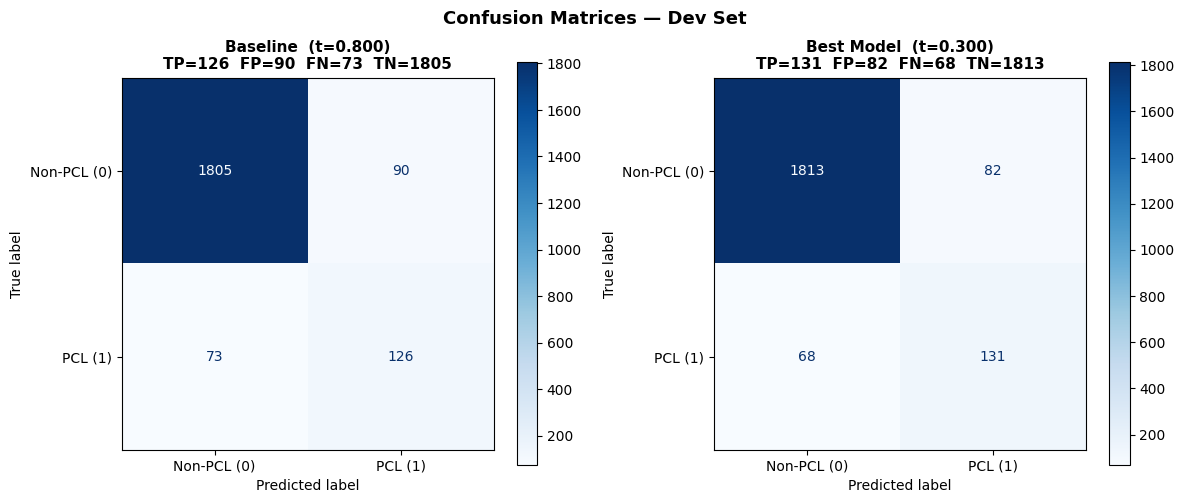

✓ Saved → confusion_matrices_ea.png

────────────────────────────────────────────────────────────
  Baseline  (threshold = 0.800)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Non-PCL (0)     0.9611    0.9525    0.9568      1895
     PCL (1)     0.5833    0.6332    0.6072       199

    accuracy                         0.9222      2094
   macro avg     0.7722    0.7928    0.7820      2094
weighted avg     0.9252    0.9222    0.9236      2094


────────────────────────────────────────────────────────────
  Best Model  (threshold = 0.300)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Non-PCL (0)     0.9638    0.9567    0.9603      1895
     PCL (1)     0.6150    0.6583    0.6359       199

    accuracy                         0.9284      2094
   macro avg     0.7894    0.8075    0.7981      2094
weighted avg     0.9307    0.9284    0.9295      2094

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ── Data: reuse predictions from the error analysis cell above ────────────────
models = [
    {"name": "Baseline",    "preds": bl_preds, "threshold": bl_thr},
    {"name": "Best Model",  "preds": bm_preds, "threshold": bm_thr},
]
labels_display = ["Non-PCL (0)", "PCL (1)"]

# ── Plot: one confusion matrix per model, side by side ────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, m in zip(axes, models):
    cm   = confusion_matrix(ea_labels, m["preds"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_display)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format="d")

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f"{m['name']}  (t={m['threshold']:.3f})\n"
        f"TP={tp}  FP={fp}  FN={fn}  TN={tn}",
        fontsize=11, fontweight="bold"
    )

fig.suptitle("Confusion Matrices — Dev Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices_ea.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved → confusion_matrices_ea.png")

# ── Per-model classification report ───────────────────────────────────────────
for m in models:
    print(f"\n{'─'*60}")
    print(f"  {m['name']}  (threshold = {m['threshold']:.3f})")
    print(f"{'─'*60}")
    print(classification_report(ea_labels, m["preds"],
                                target_names=labels_display,
                                digits=4, zero_division=0))


# Precision-Recall Curve Analysis

Plot the **Precision-Recall curve** for any saved model checkpoint.  
Provide the paths to the **full model** (`.pt` saved via `torch.save(model, ...)`) and the optional **meta checkpoint** (saved via `torch.save({...}, ...)` — used to recover the trained `best_threshold`).

The section:
1. Loads the model and tokenizer
2. Runs inference on the **dev set** (labelled) to obtain raw probabilities
3. Plots the PR curve with key operating points annotated (trained threshold, max-F1 threshold, argmax threshold)
4. Prints a summary table of precision / recall / F1 at each annotated point


In [ ]:
MODEL_NAME = "DeBERTa_baseline"
MODEL_FOLDER = f"/Users/kevinwang/Downloads"

# Path to the FULL model object (saved with torch.save(model, path))
PR_MODEL_FULL_PATH = f"{MODEL_FOLDER}/{MODEL_NAME}/best_model_full.pt"

# Path to the META checkpoint (saved with torch.save({...}, path))
# Set to None to skip threshold annotation from training.
PR_MODEL_META_PATH = f"{MODEL_FOLDER}/{MODEL_NAME}/best_model_f1.pt" # or None

# Tokenizer / model name (must match the checkpoint)
PR_TOKENIZER_NAME = "microsoft/deberta-v3-large"

# Max token length used during training
PR_MAX_LEN = 200

# Batch size for inference
PR_BATCH_SIZE = 32

# Output path for saved figure (set to None to skip saving)
PR_SAVE_FIG = f"pr_curves/pr_curve_{MODEL_NAME}.png"

print("✓ PR curve config set.")
print(f"  Model full : {PR_MODEL_FULL_PATH}")
print(f"  Model meta : {PR_MODEL_META_PATH}")
print(f"  Tokenizer  : {PR_TOKENIZER_NAME}  |  max_len={PR_MAX_LEN}")


✓ PR curve config set.
  Model full : /Users/kevinwang/Downloads/DeBERTa_baseline/best_model_full.pt
  Model meta : /Users/kevinwang/Downloads/DeBERTa_baseline/best_model_f1.pt
  Tokenizer  : microsoft/deberta-v3-large  |  max_len=200


/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece token

✓ Tokenizer loaded: microsoft/deberta-v3-large
✓ Model loaded from: /Users/kevinwang/Downloads/DeBERTa_baseline/best_model_full.pt  (device=mps)
✓ Model loaded from: /Users/kevinwang/Downloads/DeBERTa_baseline/best_model_full.pt  (device=mps)
✓ Trained threshold from meta: 0.8000
✓ Trained threshold from meta: 0.8000


PR curve inference:   0%|          | 0/66 [00:00<?, ?it/s]


✓ Inference done — 2094 samples
  Positives in ground truth : 199 / 2094

✓ Figure saved → pr_curves/pr_curve_DeBERTa_baseline.png

✓ Figure saved → pr_curves/pr_curve_DeBERTa_baseline.png


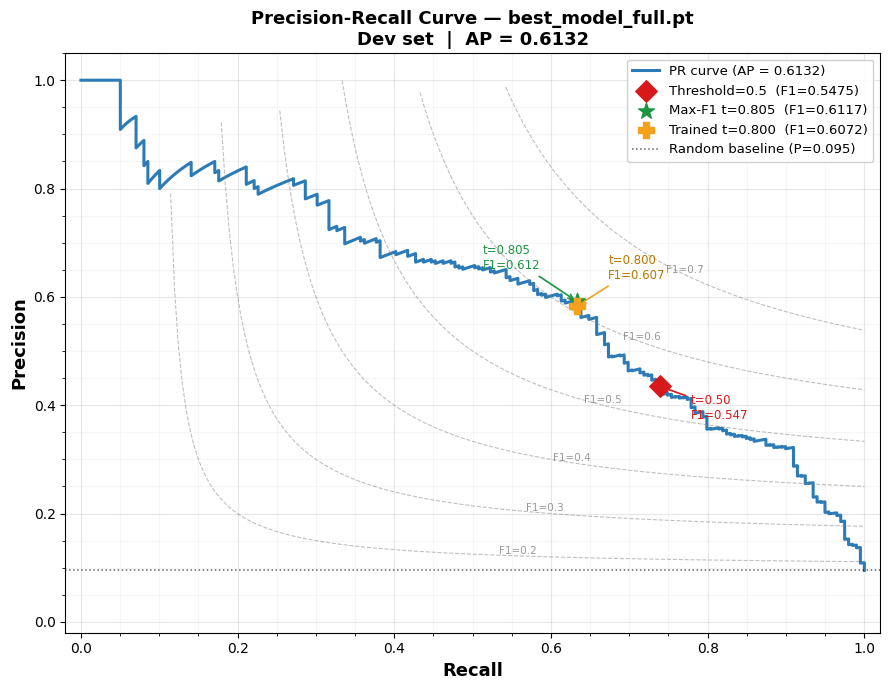


OPERATING POINT SUMMARY
Point                   Threshold  Precision    Recall        F1
--------------------------------------------------------------
  Argmax (t=0.50)          0.5000     0.4349    0.7387    0.5475
  Max-F1 (t=0.805)         0.8045     0.5915    0.6332    0.6117
  Trained (t=0.800)        0.8000     0.5833    0.6332    0.6072

  Average Precision (AP / AUC-PR) : 0.6132
  Class balance (% positive)      : 9.50%


In [ ]:
import os
import gc
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
)
from tqdm.auto import tqdm

pr_tokenizer = AutoTokenizer.from_pretrained(PR_TOKENIZER_NAME)
pr_tokenizer.model_max_length = PR_MAX_LEN
print(f"Tokenizer loaded: {PR_TOKENIZER_NAME}")

if not os.path.exists(PR_MODEL_FULL_PATH):
    raise FileNotFoundError(f"Full model checkpoint not found: {PR_MODEL_FULL_PATH}")

pr_model = torch.load(PR_MODEL_FULL_PATH, map_location="cpu", weights_only=False)
pr_model.eval()
pr_model.to(device)
print(f"Model loaded from: {PR_MODEL_FULL_PATH}  (device={device})")

trained_threshold = None
if PR_MODEL_META_PATH and os.path.exists(PR_MODEL_META_PATH):
    pr_meta = torch.load(PR_MODEL_META_PATH, map_location="cpu", weights_only=False)
    trained_threshold = float(pr_meta.get("best_threshold", 0.5))
    print(f"Trained threshold from meta: {trained_threshold:.4f}")
else:
    print("No meta checkpoint — trained threshold annotation will be skipped.")

# tedf1 contains the dev set (built earlier in this notebook)
pr_texts  = tedf1['text'].tolist()
pr_labels = tedf1['label'].astype(int).tolist()

pr_dataset = TextDataset(pr_texts, pr_labels, pr_tokenizer, max_len=PR_MAX_LEN)
pr_loader  = DataLoader(pr_dataset, batch_size=PR_BATCH_SIZE, shuffle=False)

pr_probs_all = []
pr_true_all  = []

with torch.no_grad():
    for batch in tqdm(pr_loader, desc="PR curve inference"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels']

        out    = pr_model(input_ids=input_ids, attention_mask=attention_mask)
        # Support both raw-tensor models and HuggingFace SequenceClassifierOutput
        logits = out.logits if hasattr(out, 'logits') else out
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

        pr_probs_all.extend(probs.tolist())
        pr_true_all.extend(labels.numpy().tolist())

pr_probs_arr = np.array(pr_probs_all)
pr_true_arr  = np.array(pr_true_all)

print(f"\nInference done — {len(pr_probs_arr)} samples")
print(f"Positives in ground truth : {pr_true_arr.sum()} / {len(pr_true_arr)}")

# Unload model to free memory
pr_model.cpu()
del pr_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(pr_true_arr, pr_probs_arr)
ap = average_precision_score(pr_true_arr, pr_probs_arr)

# Max-F1 threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) == 0,
    0.0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
)
best_idx      = int(np.argmax(f1_scores))
best_f1_t     = pr_thresholds[best_idx]
best_f1_prec  = precision_vals[best_idx]
best_f1_rec   = recall_vals[best_idx]
best_f1_score = f1_scores[best_idx]

# Default argmax operating point (threshold = 0.5)
argmax_preds = (pr_probs_arr >= 0.5).astype(int)
argmax_prec  = precision_score(pr_true_arr, argmax_preds, zero_division=0)
argmax_rec   = recall_score(pr_true_arr, argmax_preds, zero_division=0)
argmax_f1    = f1_score(pr_true_arr, argmax_preds, zero_division=0)

# Trained-threshold operating point
trained_prec = trained_rec = trained_f1 = None
if trained_threshold is not None:
    trained_preds = (pr_probs_arr >= trained_threshold).astype(int)
    trained_prec  = precision_score(pr_true_arr, trained_preds, zero_division=0)
    trained_rec   = recall_score(pr_true_arr, trained_preds, zero_division=0)
    trained_f1    = f1_score(pr_true_arr, trained_preds, zero_division=0)

fig, ax = plt.subplots(figsize=(9, 7))

# PR curve
ax.plot(recall_vals, precision_vals,
        color='#2c7bb6', linewidth=2.2, label=f'PR curve (AP = {ap:.4f})')

# Iso-F1 contours
for iso_f1 in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    r_pts = np.linspace(0.01, 1.0, 200)
    p_pts = iso_f1 * r_pts / (2 * r_pts - iso_f1 + 1e-9)
    mask  = (p_pts >= 0) & (p_pts <= 1.0)
    ax.plot(r_pts[mask], p_pts[mask],
            color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    if mask.any():
        mid = len(r_pts[mask]) // 2
        ax.annotate(
            f'F1={iso_f1}',
            xy=(r_pts[mask][mid], p_pts[mask][mid]),
            fontsize=7.5, color='grey', alpha=0.8,
            ha='center', va='bottom',
        )

# Operating points
ax.scatter(argmax_rec, argmax_prec,
           s=120, zorder=5, color='#d7191c',
           label=f'Threshold=0.5  (F1={argmax_f1:.4f})', marker='D')
ax.annotate(f't=0.50\nF1={argmax_f1:.3f}',
            xy=(argmax_rec, argmax_prec),
            xytext=(argmax_rec + 0.04, argmax_prec - 0.06),
            fontsize=8.5, color='#d7191c',
            arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.2))

ax.scatter(best_f1_rec, best_f1_prec,
           s=140, zorder=5, color='#1a9641',
           label=f'Max-F1 t={best_f1_t:.3f}  (F1={best_f1_score:.4f})', marker='*')
ax.annotate(f't={best_f1_t:.3f}\nF1={best_f1_score:.3f}',
            xy=(best_f1_rec, best_f1_prec),
            xytext=(best_f1_rec - 0.12, best_f1_prec + 0.06),
            fontsize=8.5, color='#1a9641',
            arrowprops=dict(arrowstyle='->', color='#1a9641', lw=1.2))

if trained_threshold is not None:
    ax.scatter(trained_rec, trained_prec,
               s=120, zorder=5, color='#f4a11d',
               label=f'Trained t={trained_threshold:.3f}  (F1={trained_f1:.4f})', marker='P')
    ax.annotate(f't={trained_threshold:.3f}\nF1={trained_f1:.3f}',
                xy=(trained_rec, trained_prec),
                xytext=(trained_rec + 0.04, trained_prec + 0.05),
                fontsize=8.5, color='#b87800',
                arrowprops=dict(arrowstyle='->', color='#f4a11d', lw=1.2))

# Baseline (random classifier)
pos_rate = pr_true_arr.mean()
ax.axhline(pos_rate, color='black', linestyle=':', linewidth=1.1, alpha=0.6,
           label=f'Random baseline (P={pos_rate:.3f})')

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title(
    f'Precision-Recall Curve — {os.path.basename(PR_MODEL_FULL_PATH)}\n'
    f'Dev set  |  AP = {ap:.4f}',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=9.5, framealpha=0.9)
ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.grid(which='major', alpha=0.3)
ax.grid(which='minor', alpha=0.1)

plt.tight_layout()
if PR_SAVE_FIG:
    plt.savefig(PR_SAVE_FIG, dpi=200, bbox_inches='tight')
    print(f"\n✓ Figure saved → {PR_SAVE_FIG}")
plt.show()

print("\n" + "=" * 62)
print("OPERATING POINT SUMMARY")
print("=" * 62)
header = f"{'Point':<22} {'Threshold':>10} {'Precision':>10} {'Recall':>9} {'F1':>9}"
print(header)
print("-" * 62)

rows_summary = [
    ("Argmax (t=0.50)",    0.50,              argmax_prec,  argmax_rec,  argmax_f1),
    (f"Max-F1 (t={best_f1_t:.3f})", best_f1_t, best_f1_prec, best_f1_rec, best_f1_score),
]
if trained_threshold is not None:
    rows_summary.append(
        (f"Trained (t={trained_threshold:.3f})", trained_threshold, trained_prec, trained_rec, trained_f1)
    )

for name, t, p, r, f in rows_summary:
    print(f"  {name:<20} {t:>10.4f} {p:>10.4f} {r:>9.4f} {f:>9.4f}")

print("=" * 62)
print(f"\n  Average Precision (AP / AUC-PR) : {ap:.4f}")
print(f"  Class balance (% positive)      : {100*pos_rate:.2f}%")


# Ensembling + Eval Metrics and Prediction Output

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

# Put the *full model object* checkpoints here (saved via: torch.save(model, "...pt"))
# Example:
# ENSEMBLE_MODEL_PATHS = [
#     "best_model_full_seed42.pt",
#     "best_model_full_seed123.pt",
# ]
print(device)
ENSEMBLE_MODEL_PATHS = [
    "/Users/kevinwang/Downloads/DeBERTa_baseline/baseline_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_L_results/DeBERTa_L_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_large_L_grad_3layers_results/DeBERTa_large_L_grad_3_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_large_L_aug_results/DeBERTa_large_L_aug_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_large_L_grad_3layers_new/DeBERTa_large_L_grad_3_new_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_large_L_new/DeBERTa_large_L_new_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_large_grad_ce/DeBERTa_large_grad_ce_model_full.pt",
    "/Users/kevinwang/Downloads/DeBERTa_best/DeBERTa_best_model_full.pt",
]

# I also saved model metas which included model thresholds found during validation.
# Not necessary here since we have a dictionary of thresholds to use
ENSEMBLE_META_PATHS = [
]

THRESHOLD_DICT = {
    "/Users/kevinwang/Downloads/DeBERTa_L_grad_results/best_model_f1.pt": 0.625,
    "/Users/kevinwang/Downloads/DeBERTa_L_results/DeBERTa_L_model_full.pt": 0.626,
    "/Users/kevinwang/Downloads/DeBERTa_large_L_grad_3layers_results/DeBERTa_large_L_grad_3_model_full.pt": 0.201,
    "/Users/kevinwang/Downloads/DeBERTa_M_grad_3layers_results/best_model_f1.pt": 0.318,
    "/Users/kevinwang/Downloads/DeBERTa_large_L_aug_results/DeBERTa_large_L_aug_model_full.pt": 0.328,
    "/Users/kevinwang/Downloads/DeBERTa_large_L_grad_3layers_new/DeBERTa_large_L_grad_3_new_model_full.pt": 0.693,
    "/Users/kevinwang/Downloads/DeBERTa_large_L_new/DeBERTa_large_L_new_model_full.p": 0.645,
    "/Users/kevinwang/Downloads/DeBERTa_large_grad_ce/DeBERTa_large_grad_ce_model_full.pt": 0.203,
    "/Users/kevinwang/Downloads/DeBERTa_best/DeBERTa_best_model_full.pt": 0.268,
    "/Users/kevinwang/Downloads/DeBERTa_baseline/baseline_model_full.pt": 0.805,
}

PRED_BATCH_SIZE = 64
MAX_LEN = 200
TEST_TSV_PATH = "task4_test.tsv"

# Thresholding rule:
#  - 'mean': use mean(thresholds) across models (if meta available)
#  - 'vote': each model votes using its own threshold, final pred = majority vote
#  - 'fixed': use FIXED_THRESHOLD
THRESHOLD_MODE = "vote"
FIXED_THRESHOLD = 0.5


def load_thresholds(meta_paths, default=0.5):
    thresholds = []
    for p in meta_paths:
        if not os.path.exists(p):
            print(f"Meta missing: {p} → using default {default}")
            thresholds.append(default)
            continue
        if p in THRESHOLD_DICT:
            t = THRESHOLD_DICT[p]
            thresholds.append(t)
            print(f"Threshold {t:.3f} from THRESHOLD_DICT for: {os.path.basename(os.path.dirname(p))}")
            continue
        meta = torch.load(p, map_location="cpu", weights_only=False)
        t = float(meta.get("best_threshold", default))
        thresholds.append(t)
        print(f"Threshold {t:.3f} from: {os.path.basename(os.path.dirname(p))}")
    return thresholds


def get_text_loader(texts, tokenizer, batch_size=16, max_len=512):
    dummy_labels = [0] * len(texts)
    ds = TextDataset(texts, dummy_labels, tokenizer, max_len=max_len)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


def predict_with_single_model(model_path, texts, tokenizer, device, batch_size=16, max_len=512, model_label="model"):
    print(f"\n Loading: {model_label}")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Checkpoint not found: {model_path}")

    m = torch.load(model_path, map_location="cpu", weights_only=False)
    m.eval()
    m.to(device)
    print(f"Loaded onto {device}")

    loader = get_text_loader(texts, tokenizer, batch_size=batch_size, max_len=max_len)
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=f"    Inference [{model_label}]", leave=False)
        for batch in pbar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            out = m(input_ids=input_ids, attention_mask=attention_mask)
            # Support both HuggingFace SequenceClassifierOutput and raw tensors
            logits = out.logits if hasattr(out, 'logits') else out
            probs  = F.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.detach().cpu().numpy().tolist())
            pbar.set_postfix({'samples': len(all_probs)})

    # Unload model and free memory
    m.cpu()
    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"    ✓ Done — {len(all_probs)} predictions, model unloaded")

    return np.array(all_probs, dtype=float)


def apply_threshold(all_model_probs, ensemble_thresholds, threshold_mode, fixed_threshold=0.5, vote_majority=2):
    stacked = np.stack(all_model_probs, axis=0)
    mean_prob = stacked.mean(axis=0)

    if threshold_mode == "vote":
        votes = np.stack(
            [(all_model_probs[i] >= ensemble_thresholds[i]).astype(int)
             for i in range(len(all_model_probs))],
            axis=0
        )
        preds = (votes.sum(axis=0) >= (vote_majority)).astype(int)
        used_t = None
        print(f"Threshold mode: VOTE (majority of {len(all_model_probs)} models)")
    elif threshold_mode == "mean":
        used_t = float(np.mean(ensemble_thresholds))
        preds = (mean_prob >= used_t).astype(int)
        print(f"Threshold mode: MEAN → {used_t:.3f}")
    else:  # fixed
        used_t = float(fixed_threshold)
        preds = (mean_prob >= used_t).astype(int)
        print(f"Threshold mode: FIXED → {used_t:.3f}")

    return preds, mean_prob, used_t


def run_ensemble_inference(texts, model_paths, tokenizer, device, thresholds,
                           batch_size=16, max_len=512, set_label="set",
                           threshold_mode="vote", fixed_threshold=0.5, eval_y_true=None, vote_majority=None):
    print("\n" + "=" * 70)
    print(f"ENSEMBLE INFERENCE: {set_label.upper()}  ({len(texts)} samples, {len(model_paths)} models)")
    print("=" * 70)

    all_model_probs = []
    outer_pbar = tqdm(enumerate(model_paths), total=len(model_paths), desc="Models", unit="model")
    for i, model_path in outer_pbar:
        label = f"{i+1}/{len(model_paths)}: {os.path.basename(os.path.dirname(model_path))}"
        outer_pbar.set_postfix({'current': os.path.basename(os.path.dirname(model_path))})
        probs = predict_with_single_model(
            model_path, texts, tokenizer, device,
            batch_size=batch_size, max_len=max_len, model_label=label
        )
        all_model_probs.append(probs)
        print(f"Model {i+1} mean P(PCL): {probs.mean():.4f}")

    stacked = np.stack(all_model_probs, axis=0)
    mean_prob = stacked.mean(axis=0)
    print(f"\nAveraged probabilities across {len(all_model_probs)} models")
    print(f"Ensemble mean P(PCL): {mean_prob.mean():.4f}  |  std: {mean_prob.std():.4f}")

    best_f1 = 0.0
    best_preds = None
    best_mean_prob = None
    best_used_t = None
    best_vote_majority = None
    if eval_y_true is not None and vote_majority is None:
        for i in range(1, len(all_model_probs) + 1):
            preds, mean_prob, used_t = apply_threshold(
                all_model_probs, thresholds, threshold_mode, fixed_threshold, vote_majority=i
            )
            acc  = accuracy_score(eval_y_true, preds)
            prec = precision_score(eval_y_true, preds, zero_division=0)
            rec  = recall_score(eval_y_true, preds, zero_division=0)
            f1   = f1_score(eval_y_true, preds, zero_division=0)
            print(f"Using majority vote of {i} models → F1: {f1:.4f}, Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}")
            if f1 > best_f1:
                best_f1 = f1
                best_preds = preds
                best_mean_prob = mean_prob
                best_used_t = used_t
                best_vote_majority = i
    else:
        best_preds, best_mean_prob, best_used_t = apply_threshold(
            all_model_probs, thresholds, threshold_mode, fixed_threshold, vote_majority=vote_majority
        )

    return best_preds, best_mean_prob, best_used_t, best_vote_majority


# Load thresholds + tokenizer
print("=" * 70)
print("LOADING ENSEMBLE THRESHOLDS")
print("=" * 70)
ensemble_thresholds = load_thresholds(ENSEMBLE_META_PATHS, default=0.5)
print(f"\n  Thresholds : {[f'{t:.3f}' for t in ensemble_thresholds]}")
print(f"  Mean       : {np.mean(ensemble_thresholds):.3f}")

from transformers import AutoTokenizer
set_model_name = "microsoft/deberta-v3-base" # The tokeniser is the same for base and large, so we can just pick one to load here for inference.
tokenizer = AutoTokenizer.from_pretrained(set_model_name)
tokenizer.model_max_length = 200
print(f"\nTokenizer loaded: {set_model_name}")


# DEV SET ensemble inference
# tedf1 was shuffled (random_state=42) earlier — run inference on the shuffled
# order, then re-sort results back to the original dev_semeval_parids-labels.csv
# order before writing the submission file.

# Load the original dev par_id order directly from the CSV
dev_csv_order = pd.read_csv('dev_semeval_parids-labels.csv')
dev_csv_order['par_id'] = dev_csv_order['par_id'].astype(str)
print(f"  Original dev CSV order: {len(dev_csv_order)} par_ids")

eval_texts_full  = tedf1['text'].tolist()
eval_y_true_full = tedf1['label'].astype(int).values

eval_texts = eval_texts_full
eval_y_true = eval_y_true_full

y_pred_dev, y_prob_dev, used_threshold_dev, best_vote_majority = run_ensemble_inference(
    eval_texts, ENSEMBLE_MODEL_PATHS, tokenizer, device, ensemble_thresholds,
    batch_size=PRED_BATCH_SIZE, max_len=MAX_LEN, set_label="Dev/Eval",
    threshold_mode=THRESHOLD_MODE, fixed_threshold=FIXED_THRESHOLD, eval_y_true=eval_y_true
)

# Metrics (computed on shuffled order — fine for metrics)
acc  = accuracy_score(eval_y_true, y_pred_dev)
prec = precision_score(eval_y_true, y_pred_dev, zero_division=0)
rec  = recall_score(eval_y_true, y_pred_dev, zero_division=0)
f1   = f1_score(eval_y_true, y_pred_dev, zero_division=0)

print("\n" + "=" * 70)
print("ENSEMBLE EVAL METRICS (dev/eval)")
print("=" * 70)
print(f"  Models           : {len(ENSEMBLE_MODEL_PATHS)}")
print(f"  Threshold mode   : {THRESHOLD_MODE}")
if used_threshold_dev is not None:
    print(f"  Used threshold   : {used_threshold_dev:.3f}")
print(f"  Accuracy         : {acc:.4f}")
print(f"  Precision        : {prec:.4f}")
print(f"  Recall           : {rec:.4f}")
print(f"  F1               : {f1:.4f}")
print("\nConfusion matrix:\n", confusion_matrix(eval_y_true, y_pred_dev))
print("\nClassification report:\n", classification_report(eval_y_true, y_pred_dev, digits=4, zero_division=0))

# Re-sort to original dev_semeval_parids-labels.csv order
# Attach predictions to the (currently shuffled) tedf1 par_ids
dev_result_df = tedf1[['par_id']].copy()
dev_result_df['par_id'] = dev_result_df['par_id'].astype(str)
dev_result_df['prob']  = y_prob_dev
dev_result_df['pred']  = y_pred_dev
dev_result_df['label'] = eval_y_true  # for reference, not needed for submission

# Merge with the original CSV order to restore correct row ordering
dev_result_df = dev_csv_order[['par_id']].merge(dev_result_df, on='par_id', how='left')

print(f"\nRe-sorted {len(dev_result_df)} dev predictions to match dev_semeval_parids-labels.csv order")
assert len(dev_result_df) == len(dev_csv_order), "Row count mismatch after re-sort!"
assert dev_result_df['pred'].isna().sum() == 0, "Some par_ids missing from predictions!"

# Write .txt in submission order (one label per line, no header)
with open("predictions_eval_ensemble_latest.txt", "w") as f:
    for p in dev_result_df['pred']:
        f.write(f"{int(p)}\n")
print("Wrote dev ensemble predictions (original CSV order) → predictions_eval_ensemble_latest.txt")

dev_result_df.to_csv("predictions_eval_ensemble_with_probs_latest.csv", index=False)
print("Wrote dev probs/preds → predictions_eval_ensemble_with_probs_latest.csv")


# TEST SET ensemble inference
print("\n" + "=" * 70)
print("LOADING TEST SET")
print("=" * 70)

test_df = pd.read_csv(
    TEST_TSV_PATH,
    sep='\t',
    header=None,
    names=['id', 'par_id', 'community', 'country', 'text'],
    quoting=3,
    engine='python'
)
print(f"Test rows loaded: {len(test_df)}")
print(test_df.head(3).to_string(index=False))

test_texts = test_df['text'].tolist()

print(f"Inference on TEST set with majority vote of {best_vote_majority} models (same as best on dev)...")
y_pred_test, y_prob_test, used_threshold_test, _ = run_ensemble_inference(
    test_texts, ENSEMBLE_MODEL_PATHS, tokenizer, device, ensemble_thresholds,
    batch_size=PRED_BATCH_SIZE, max_len=MAX_LEN, set_label="Test",
    threshold_mode=THRESHOLD_MODE, fixed_threshold=FIXED_THRESHOLD, vote_majority=best_vote_majority
)

pos = int(y_pred_test.sum())
print(f"\nPositive (PCL): {pos}/{len(y_pred_test)}  ({100*pos/len(y_pred_test):.1f} %)")

# Write test outputs
with open("predictions_test_ensemble_latest.txt", "w") as f:
    for p in y_pred_test:
        f.write(f"{int(p)}\n")
print("Wrote test ensemble predictions → predictions_test_ensemble_latest.txt")

test_out_df = test_df[['id', 'par_id']].copy()
test_out_df['prob'] = y_prob_test
test_out_df['pred'] = y_pred_test
test_out_df.to_csv("predictions_test_ensemble_with_probs_latest.csv", index=False)
print("Wrote test probs/preds → predictions_test_ensemble_with_probs_latest.csv")


mps
LOADING ENSEMBLE THRESHOLDS
  ✓ Threshold 0.805 from THRESHOLD_DICT for: DeBERTa_baseline
  ✓ Threshold 0.626 from THRESHOLD_DICT for: DeBERTa_L_results
  ✓ Threshold 0.201 from THRESHOLD_DICT for: DeBERTa_large_L_grad_3layers_results
  ✓ Threshold 0.328 from THRESHOLD_DICT for: DeBERTa_large_L_aug_results
  ✓ Threshold 0.693 from THRESHOLD_DICT for: DeBERTa_large_L_grad_3layers_new
  ✓ Threshold 0.645 from THRESHOLD_DICT for: DeBERTa_large_L_new
  ✓ Threshold 0.203 from THRESHOLD_DICT for: DeBERTa_large_grad_ce
  ✓ Threshold 0.268 from THRESHOLD_DICT for: DeBERTa_large_grad_g1

  Thresholds : ['0.805', '0.626', '0.201', '0.328', '0.693', '0.645', '0.203', '0.268']
  Mean       : 0.471


/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
/Users/kevinwang/.pyenv/versions/iml_nn_env/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece token


  ✓ Tokenizer loaded: microsoft/deberta-v3-base
  Original dev CSV order: 2094 par_ids

ENSEMBLE INFERENCE: DEV/EVAL  (2094 samples, 8 models)


Models:   0%|          | 0/8 [00:00<?, ?model/s]


  → Loading: 1/8: DeBERTa_baseline
    ✓ Loaded onto mps
    ✓ Loaded onto mps


...

    ✓ Done — 3832 predictions, model unloaded
  Model 6 mean P(PCL): 0.1391

  → Loading: 7/8: DeBERTa_large_grad_ce
    ✓ Loaded onto mps
    ✓ Loaded onto mps


    Inference [7/8: DeBERTa_large_grad_ce]:   0%|          | 0/60 [00:00<?, ?it/s]

    ✓ Done — 3832 predictions, model unloaded
  Model 7 mean P(PCL): 0.0742

  → Loading: 8/8: DeBERTa_large_grad_g1
    ✓ Loaded onto mps
    ✓ Loaded onto mps


    Inference [8/8: DeBERTa_large_grad_g1]:   0%|          | 0/60 [00:00<?, ?it/s]

    ✓ Done — 3832 predictions, model unloaded
  Model 8 mean P(PCL): 0.0790

  ✓ Averaged probabilities across 8 models
  Ensemble mean P(PCL): 0.1133  |  std: 0.2301
  Threshold mode: VOTE (majority of 8 models)

  Positive (PCL): 365/3832  (9.5 %)
✓ Wrote test ensemble predictions → predictions_test_ensemble_latest.txt
✓ Wrote test probs/preds → predictions_test_ensemble_with_probs_latest.csv


### Freeing up CUDA Memory

If you're still encountering `OutOfMemoryError`, you can explicitly try to free up memory by clearing PyTorch's CUDA cache and deleting variables that are no longer in use. This can help prevent memory fragmentation and allow more memory to be allocated for subsequent operations.

In [ ]:
import gc
import torch

def clear_memory():
    """
    Clear memory across different device types.
    Handles CUDA, MPS, and CPU appropriately.
    """
    # Explicit garbage collection
    gc.collect()
    print("✓ Python garbage collector invoked")

    # Clear PyTorch cache based on device type
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print("✓ CUDA cache cleared and synchronized")

    elif torch.backends.mps.is_available():
        # MPS uses shared system memory, force Python GC more aggressively
        gc.collect()
        print("✓ MPS memory cleared (shared system memory)")

    else:
        print("✓ Running on CPU - standard memory management")

clear_memory()
print("\nMemory clearing operations completed successfully!")

✓ Python garbage collector invoked
✓ CUDA cache cleared and synchronized

Memory clearing operations completed successfully!


# Predictions Generation (OLD NO ENSEMBLING)

In [40]:
meta = torch.load("best_model_f1.pt", map_location="cpu", weights_only=False)

In [41]:
model.load_state_dict(meta["model_state_dict"])

<All keys matched successfully>

In [39]:
# Evaluation phase
model.eval() # Set model to evaluation mode
total_test_loss = 0
all_predictions = [] # This will still store the argmax predictions as a baseline
all_probabilities = [] # To store probabilities for thresholding
all_true_labels = []

# Wrap test_loader with tqdm for a progress bar during evaluation
eval_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1} Evaluating")
with torch.no_grad(): # Disable gradient calculations during evaluation
    total_val_loss = 0
    for batch_idx, batch in enumerate(eval_pbar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits if hasattr(outputs, 'logits') else outputs
        loss = criterion(logits, labels)
        total_test_loss += loss.item()

        # Store argmax predictions for baseline F1/Accuracy
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        all_predictions.extend(predictions)

        # Store probabilities for threshold-based evaluation
        probabilities = F.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probability of positive class
        all_probabilities.extend(probabilities)

        true_labels_batch = labels.cpu().numpy()
        all_true_labels.extend(true_labels_batch)

        total_val_loss += loss.item()
        eval_pbar.set_postfix({'batch_loss': loss.item(), 'average loss': total_val_loss / (batch_idx + 1)})

avg_test_loss = total_test_loss / len(test_loader)

# Calculate and print F1/Accuracy for original argmax predictions
f1_argmax = f1_score(all_true_labels, all_predictions, average='binary')
accuracy_argmax = accuracy_score(all_true_labels, all_predictions)
print(f"Epoch {epoch+1} Test Loss: {avg_test_loss:.4f}, Baseline (argmax) F1 Score: {f1_argmax:.4f}, Accuracy: {accuracy_argmax:.4f}")

# Evaluate with different thresholds
thresholds = np.arange(0.1, 1.0, 0.1)

best_epoch_f1 = 0.0
best_epoch_threshold = None

for threshold in thresholds:
    threshold_predictions = (np.array(all_probabilities) >= threshold).astype(int)
    f1_thresh = f1_score(all_true_labels, threshold_predictions, average='binary')

    if f1_thresh > best_epoch_f1:
        best_epoch_f1 = f1_thresh
        best_epoch_threshold = threshold

print(
    f"Epoch {epoch+1} Best Threshold F1: {best_epoch_f1:.4f} "
    f"(threshold={best_epoch_threshold:.2f})"
)

Epoch 15 Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch 15 Test Loss: 0.1435, Baseline (argmax) F1 Score: 0.6034, Accuracy: 0.9322
Epoch 15 Best Threshold F1: 0.6290 (threshold=0.20)


In [40]:
import os
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ──────────────────────────────────────────────────────────────────────────────
# Helper: run inference on a list of texts, return (preds, probs)
# ──────────────────────────────────────────────────────────────────────────────
def predict_texts(texts, model, tokenizer, device, threshold=0.5, batch_size=16, max_len=512):
    dummy_labels = [0] * len(texts)
    dataset = TextDataset(texts, dummy_labels, tokenizer, max_len=max_len)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_probs, all_preds = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds  = (probs >= threshold).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
    return all_preds, all_probs


def write_predictions(preds, path):
    with open(path, "w") as f:
        for p in preds:
            f.write(f"{p}\n")
    print(f"  ✓ Saved {len(preds)} predictions → {path}")


# ──────────────────────────────────────────────────────────────────────────────
# 1.  DEV SET  (dev_semeval_parids-labels.csv  →  join with dpm.train_task1_df)
#     tedf1 is already built by the data-loading cells above, so we just reuse it.
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("DEV SET PREDICTIONS")
print("=" * 60)
inference_model = model
inf_tokenizer = tokenizer
pred_threshold = meta["best_threshold"]
print(f"Using pred_threshold {pred_threshold}")
PRED_BATCH_SIZE = BATCH_SIZE

# tedf1 was built from dev_semeval_parids-labels.csv earlier in the notebook.
# It has columns: par_id, community, text, label  (shuffled with seed 42).
# We sort by par_id to restore the original file order for submission.
tedf1_sorted = tedf1.copy()
# par_id is a string like "3449225"; sort numerically
tedf1_sorted['_sort_key'] = tedf1_sorted['par_id'].astype(int)
tedf1_sorted = tedf1_sorted.sort_values('_sort_key').reset_index(drop=True)
tedf1_sorted.drop(columns='_sort_key', inplace=True)

dev_texts = tedf1_sorted['text'].tolist()
dev_pids  = tedf1_sorted['par_id'].tolist()

print(f"Dev texts loaded: {len(dev_texts)}")
dev_preds, dev_probs = predict_texts(
    dev_texts, inference_model, inf_tokenizer,
    device, threshold=pred_threshold, batch_size=PRED_BATCH_SIZE
)
write_predictions(dev_preds, "predictions_dev.txt")

pos = sum(dev_preds)
print(f"  Positive (PCL): {pos}/{len(dev_preds)}  ({100*pos/len(dev_preds):.1f} %)")


# ──────────────────────────────────────────────────────────────────────────────
# 2.  TEST SET  (task4_test.tsv)
#     Columns (no header): id, par_id, community, country, text
# ──────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("TEST SET PREDICTIONS  (task4_test.tsv)")
print("=" * 60)

TEST_TSV_PATH = "task4_test.tsv"

test_df = pd.read_csv(
    TEST_TSV_PATH,
    sep='\t',
    header=None,
    names=['id', 'par_id', 'community', 'country', 'text'],
    quoting=3,          # QUOTE_NONE — some rows contain bare quotes
    engine='python'
)

print(f"Test rows loaded: {len(test_df)}")
print(f"Columns: {list(test_df.columns)}")
print(test_df.head(3).to_string(index=False))

test_texts = test_df['text'].tolist()
test_ids   = test_df['id'].tolist()

test_preds, test_probs = predict_texts(
    test_texts, inference_model, inf_tokenizer,
    device, threshold=pred_threshold, batch_size=PRED_BATCH_SIZE
)
write_predictions(test_preds, "predictions_test.txt")

pos = sum(test_preds)
print(f"  Positive (PCL): {pos}/{len(test_preds)}  ({100*pos/len(test_preds):.1f} %)")


# ──────────────────────────────────────────────────────────────────────────────
# 3.  Optional: save a CSV with id + prediction for easy inspection
# ──────────────────────────────────────────────────────────────────────────────
dev_results  = tedf1_sorted[['par_id']].copy()
dev_results['pred']  = dev_preds
dev_results['prob']  = [f"{p:.4f}" for p in dev_probs]
dev_results['label'] = tedf1_sorted['label'].values   # ground-truth available for dev
dev_results.to_csv("predictions_dev_with_ids.csv", index=False)
print("\n  ✓ Dev predictions + IDs → predictions_dev_with_ids.csv")

test_results = test_df[['id', 'par_id']].copy()
test_results['pred'] = test_preds
test_results['prob'] = [f"{p:.4f}" for p in test_probs]
test_results.to_csv("predictions_test_with_ids.csv", index=False)
print("  ✓ Test predictions + IDs → predictions_test_with_ids.csv")


DEV SET PREDICTIONS
Using pred_threshold 0.2
Dev texts loaded: 2094
  ✓ Saved 2094 predictions → predictions_dev.txt
  Positive (PCL): 208/2094  (9.9 %)

TEST SET PREDICTIONS  (task4_test.tsv)
Test rows loaded: 3832
Columns: ['id', 'par_id', 'community', 'country', 'text']
 id     par_id  community country                                                                                                                                                                                                                                                                                                                         text
t_0  @@7258997 vulnerable      us                                                                               In the meantime , conservatives are working to weaken Clinton and drive down her numbers in early voting states , where she is increasingly vulnerable . They are , in effect , doing Sanders 's dirty work for him while he avoids scrutiny .
t_1 @@16397324      wome

### Freeing up CUDA Memory

If you're still encountering `OutOfMemoryError`, you can explicitly try to free up memory by clearing PyTorch's CUDA cache and deleting variables that are no longer in use. This can help prevent memory fragmentation and allow more memory to be allocated for subsequent operations.

In [23]:
import gc
import torch

def clear_memory():
    """
    Clear memory across different device types.
    Handles CUDA, MPS, and CPU appropriately.
    """
    # Explicit garbage collection
    gc.collect()
    print("✓ Python garbage collector invoked")

    # Clear PyTorch cache based on device type
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print("✓ CUDA cache cleared and synchronized")

    elif torch.backends.mps.is_available():
        # MPS uses shared system memory, force Python GC more aggressively
        gc.collect()
        print("✓ MPS memory cleared (shared system memory)")

    else:
        print("✓ Running on CPU - standard memory management")

clear_memory()
print("\nMemory clearing operations completed successfully!")

✓ Python garbage collector invoked
✓ CUDA cache cleared and synchronized

Memory clearing operations completed successfully!
